# 1. Notebook Setup

In [1]:
import os, random, numpy as np, pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.neighbors import KNeighborsClassifier

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

print("Device:", DEVICE)

Device: cuda


# 2. AMP

In [2]:
if torch.cuda.is_available():
    from torch.cuda.amp import autocast, GradScaler
    scaler = GradScaler()
    AMP_ENABLED = True
else:
    from contextlib import nullcontext
    autocast = nullcontext
    scaler = None
    AMP_ENABLED = False

/tmp/ipykernel_23/2803221640.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


# 3. Load Dataset

In [3]:
import os
import pandas as pd

base_path = "/kaggle/input/datasets/saifewu/py-crackdb/Classification"

data = []

for label_name in ["With crack", "Without crack"]:
    class_path = os.path.join(base_path, label_name)

    for img in os.listdir(class_path):
        data.append({
            "image_path": os.path.join(class_path, img),
            "label": 1 if label_name == "With crack" else 0
        })

df = pd.DataFrame(data)

print("Total images:", len(df))
print(df.head())

Total images: 569
                                          image_path  label
0  /kaggle/input/datasets/saifewu/py-crackdb/Clas...      1
1  /kaggle/input/datasets/saifewu/py-crackdb/Clas...      1
2  /kaggle/input/datasets/saifewu/py-crackdb/Clas...      1
3  /kaggle/input/datasets/saifewu/py-crackdb/Clas...      1
4  /kaggle/input/datasets/saifewu/py-crackdb/Clas...      1


# 3.1 Train-Test Split

In [4]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)

print("Train size:", len(train_df))
print("Test size:", len(test_df))

Train size: 455
Test size: 114


# 4. Dataset Class

In [5]:
class SimCLRDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img = Image.open(self.df.loc[idx, "image_path"]).convert("RGB")

        xi = self.transform(img)
        xj = self.transform(img)

        return xi, xj

# 5. Augmentation

In [6]:
simclr_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomApply([
        transforms.ColorJitter(0.4,0.4,0.4,0.1)
    ], p=0.8),
    transforms.RandomGrayscale(p=0.2),
    transforms.GaussianBlur(23),
    transforms.ToTensor(),
])

# 6. Model

In [7]:
class SimCLRModel(nn.Module):
    def __init__(self, projection_dim=128):
        super().__init__()

        self.encoder = models.resnet18(weights="IMAGENET1K_V1")
        num_ftrs = self.encoder.fc.in_features
        self.encoder.fc = nn.Identity()

        self.projector = nn.Sequential(
            nn.Linear(num_ftrs, 512),
            nn.ReLU(),
            nn.Linear(512, projection_dim)
        )

    def forward(self, x):
        h = self.encoder(x)
        z = self.projector(h)
        z = F.normalize(z, dim=1)
        return h, z

# 7. FIXED NT-Xent Loss

In [8]:
def nt_xent_loss(z_i, z_j, temperature=0.5):
    batch_size = z_i.size(0)
    device = z_i.device

    z = torch.cat([z_i, z_j], dim=0)

    sim = F.cosine_similarity(
        z.unsqueeze(1), z.unsqueeze(0), dim=2
    )

    mask = torch.eye(2 * batch_size, dtype=torch.bool).to(device)
    sim = sim.masked_fill(mask, -9e15)

    labels = torch.arange(2 * batch_size).to(device)
    labels = (labels + batch_size) % (2 * batch_size)

    logits = sim / temperature

    return F.cross_entropy(logits, labels)

# 8. DataLoader

In [9]:
dataset = SimCLRDataset(train_df, simclr_transform)

loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    drop_last=True
)

# 9. Training Function

In [10]:
def train(model, loader, epochs=125, accumulation=4):
    optimizer = optim.Adam(model.parameters(), lr=3e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    class EarlyStopping:
        def __init__(self, patience=8):
            self.best = float("inf")
            self.counter = 0
            self.stop = False
            self.patience = patience

        def step(self, loss):
            if loss < self.best:
                self.best = loss
                self.counter = 0
            else:
                self.counter += 1
                if self.counter >= self.patience:
                    self.stop = True

    early = EarlyStopping()
    history = []

    model.train()

    for epoch in range(epochs):
        total_loss = 0
        optimizer.zero_grad()

        for i, (xi, xj) in enumerate(loader):
            xi, xj = xi.to(DEVICE), xj.to(DEVICE)

            with autocast():
                _, zi = model(xi)
                _, zj = model(xj)
                loss = nt_xent_loss(zi, zj) / accumulation

            if AMP_ENABLED:
                scaler.scale(loss).backward()

                if (i+1) % accumulation == 0:
                    scaler.step(optimizer)
                    scaler.update()
                    optimizer.zero_grad()
            else:
                loss.backward()

                if (i+1) % accumulation == 0:
                    optimizer.step()
                    optimizer.zero_grad()

            total_loss += loss.item()

        avg = total_loss / len(loader)
        history.append(avg)
        scheduler.step()

        print(f"Epoch {epoch+1}: Loss={avg:.4f}")

        early.step(avg)
        if early.stop:
            print("Early stopping")
            break

    return history

# 10. Train

In [11]:
model = SimCLRModel().to(DEVICE)

loss_history = train(model, loader, epochs=125)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 195MB/s]
/tmp/ipykernel_23/948452668.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 1: Loss=0.9216
Epoch 2: Loss=0.8003
Epoch 3: Loss=0.7633
Epoch 4: Loss=0.7409
Epoch 5: Loss=0.7304
Epoch 6: Loss=0.7136
Epoch 7: Loss=0.7268
Epoch 8: Loss=0.6993
Epoch 9: Loss=0.7081
Epoch 10: Loss=0.7018
Epoch 11: Loss=0.6877
Epoch 12: Loss=0.6990
Epoch 13: Loss=0.6897
Epoch 14: Loss=0.6831
Epoch 15: Loss=0.6745
Epoch 16: Loss=0.6756
Epoch 17: Loss=0.6738
Epoch 18: Loss=0.6794
Epoch 19: Loss=0.6690
Epoch 20: Loss=0.6682
Epoch 21: Loss=0.6670
Epoch 22: Loss=0.6741
Epoch 23: Loss=0.6646
Epoch 24: Loss=0.6721
Epoch 25: Loss=0.6614
Epoch 26: Loss=0.6609
Epoch 27: Loss=0.6665
Epoch 28: Loss=0.6601
Epoch 29: Loss=0.6616
Epoch 30: Loss=0.6549
Epoch 31: Loss=0.6548
Epoch 32: Loss=0.6628
Epoch 33: Loss=0.6573
Epoch 34: Loss=0.6496
Epoch 35: Loss=0.6398
Epoch 36: Loss=0.6551
Epoch 37: Loss=0.6516
Epoch 38: Loss=0.6524
Epoch 39: Loss=0.6454
Epoch 40: Loss=0.6430
Epoch 41: Loss=0.6424
Epoch 42: Loss=0.6420
Epoch 43: Loss=0.6501
Early stopping


# 11. Plot Loss

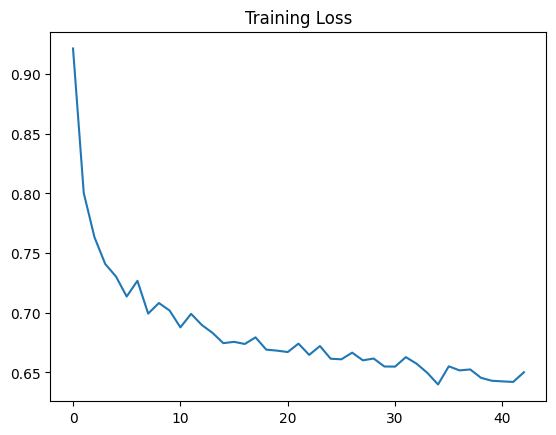

In [12]:
plt.plot(loss_history)
plt.title("Training Loss")
plt.show()

# 12. Feature Extraction

In [13]:
eval_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

def extract(model, df):
    model.eval()
    feats, labs = [], []

    with torch.no_grad():
        for _, row in df.iterrows():
            img = Image.open(row["image_path"]).convert("RGB")
            img = eval_transform(img).unsqueeze(0).to(DEVICE)

            h,_ = model(img)

            feats.append(h.cpu().numpy().flatten())
            labs.append(row["label"])

    return np.array(feats), np.array(labs)

train_features, train_labels = extract(model, train_df)
test_features, test_labels = extract(model, test_df)

# 13. Linear Probe

In [14]:
clf = LogisticRegression(max_iter=1000)

clf.fit(train_features, train_labels)

preds = clf.predict(test_features)

print("Accuracy:", accuracy_score(test_labels, preds))
print(classification_report(test_labels, preds))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        40
           1       1.00      1.00      1.00        74

    accuracy                           1.00       114
   macro avg       1.00      1.00      1.00       114
weighted avg       1.00      1.00      1.00       114



# 13.1 Confusion Matrix

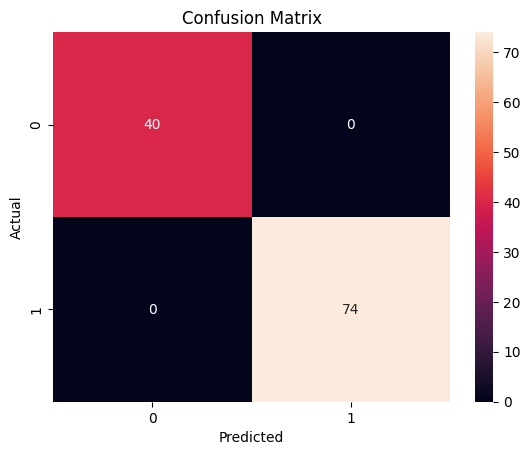

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(test_labels, preds)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 14. k-NN

In [16]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(train_features, train_labels)

preds = knn.predict(test_features)

print("kNN Accuracy:", accuracy_score(test_labels, preds))

kNN Accuracy: 1.0


# 15. Label Efficiency

In [17]:
ratios = [0.01,0.05,0.1,0.25,0.5]

for r in ratios:
    X_sub, _, y_sub, _ = train_test_split(
        train_features,
        train_labels,
        train_size=r,
        stratify=train_labels,
        random_state=SEED
    )

    clf = LogisticRegression(max_iter=1000)
    clf.fit(X_sub, y_sub)
    
    acc = clf.score(test_features, test_labels)
    print(f"{int(r*100)}% → {acc:.4f}")

1% → 0.8596
5% → 0.9737
10% → 1.0000
25% → 1.0000
50% → 1.0000


# 16. Save Model

In [18]:
torch.save(model.state_dict(), "simclr_encoder.pth")
np.save("train_features.npy", train_features)
np.save("test_features.npy", test_features)